# TELCO CUSTOMER CHURN
# Data cleaning

In [30]:
import pandas as pd

In [31]:
telco_customer_churn = pd.read_csv("../../1_data/1_raw/Telco-Customer-Churn.csv")

In [32]:
telco_customer_churn 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [33]:
telco_customer_churn.shape

(7043, 21)

In [34]:
telco_customer_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [35]:
telco_customer_churn.describe(include='str')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [36]:
#checking for missing values
telco_customer_churn.isnull().sum()*100 / len(telco_customer_churn)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [37]:
#checking for empty values
(telco_customer_churn == "").sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [38]:
#checking for duplicates
telco_customer_churn.duplicated().sum()

np.int64(0)

In [39]:
#converting the "TotalCharges" variable to a numerical type and replacing the empty values with 0
telco_customer_churn["TotalCharges"] = pd.to_numeric(telco_customer_churn["TotalCharges"], errors="coerce")
telco_customer_churn["TotalCharges"] = telco_customer_churn["TotalCharges"].fillna(0)

In [40]:
#checking unique values
for col in telco_customer_churn.select_dtypes(include="str"):
    print(f"\n{col}")
    print(telco_customer_churn[col].unique())


customerID
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection
<Arrow

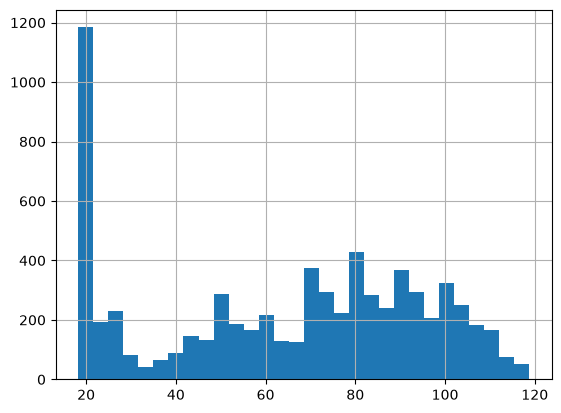

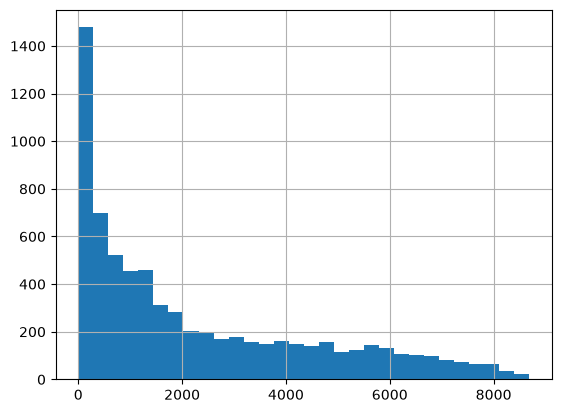

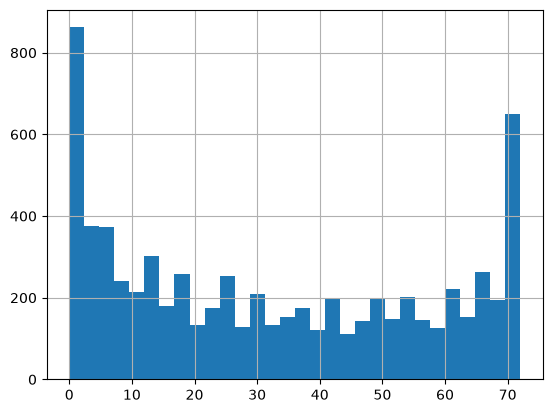

In [41]:
#checking the distribution of numerical variables
import matplotlib.pyplot as plt

telco_customer_churn["MonthlyCharges"].hist(bins=30)
plt.show()
telco_customer_churn["TotalCharges"].hist(bins=30)
plt.show()
telco_customer_churn["tenure"].hist(bins=30)
plt.show()

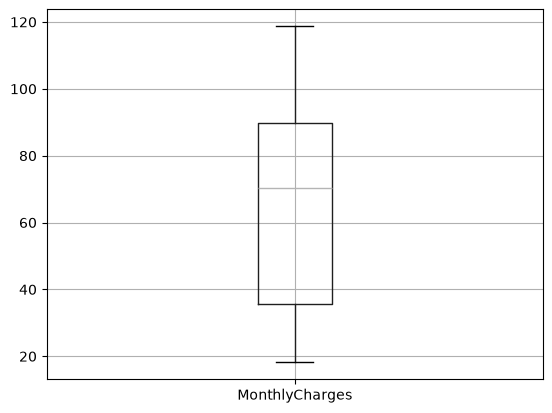

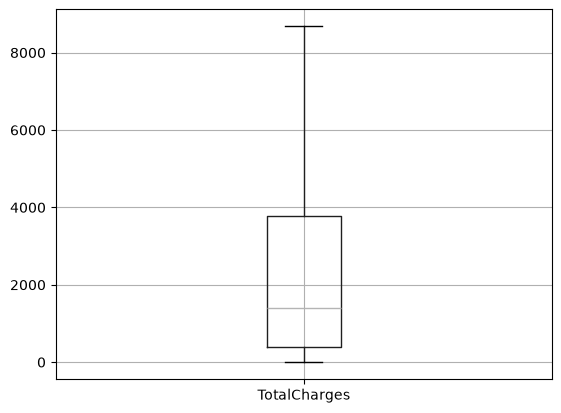

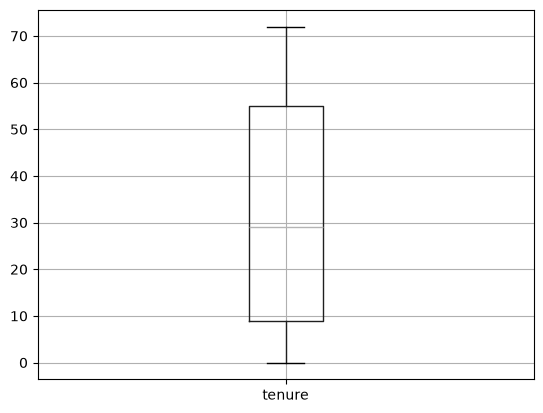

In [42]:
#checking the distribution of outliers
telco_customer_churn.boxplot(column="MonthlyCharges")
plt.show()
telco_customer_churn.boxplot(column="TotalCharges")
plt.show()
telco_customer_churn.boxplot(column="tenure")
plt.show()

In [43]:
telco_customer_churn.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


In [44]:
#checking the columns
telco_customer_churn.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [45]:
#standardizing the columns
telco_customer_churn.columns = (
    telco_customer_churn.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [46]:
telco_customer_churn.rename(
    columns={
        "customerid": "customer_id",
        "seniorcitizen": "senior_citizen",
        "phoneservice": "phone_service",
        "internetservice": "internet_service",
        "multiplelines": "multiple_lines",
        "onlinesecurity": "online_security",
        "onlinebackup": "online_backup",
        "deviceprotection": "device_protection",
        "techsupport": "tech_support",
        "streamingtv": "streaming_tv",
        "streamingmovies": "streaming_movies",
        "paperlessbilling": "paperless_billing",
        "paymentmethod": "payment_method",
        "monthlycharges": "monthly_charges",
        "totalcharges": "total_charges"
    }, inplace=True
)

In [47]:
#checking numerical variables for impossible values
(telco_customer_churn["tenure"] < 0).sum()

np.int64(0)

In [48]:
(telco_customer_churn["monthly_charges"] < 0).sum()

np.int64(0)

In [49]:
(telco_customer_churn["total_charges"] < 0).sum()

np.int64(0)

In [50]:
#checking the churn
telco_customer_churn["churn"].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [51]:
telco_customer_churn["churn"].value_counts(normalize=True) * 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [52]:
#removing the customer_id column (It's not a meaningful predictive variable) (x,y for machine learning)
x = telco_customer_churn.drop(columns=["customer_id","churn"])
y = telco_customer_churn["churn"]

In [53]:
telco_customer_churn.to_csv(
    "../../1_data/2_processed/telco_churn_clean.csv",
    index=False
)

In [54]:
#checking the new clean dataset
telco_customer_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   gender             7043 non-null   str    
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   str    
 4   dependents         7043 non-null   str    
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   str    
 7   multiple_lines     7043 non-null   str    
 8   internet_service   7043 non-null   str    
 9   online_security    7043 non-null   str    
 10  online_backup      7043 non-null   str    
 11  device_protection  7043 non-null   str    
 12  tech_support       7043 non-null   str    
 13  streaming_tv       7043 non-null   str    
 14  streaming_movies   7043 non-null   str    
 15  contract           7043 non-null   str    
 16  paperless_billing  7043 non-null   

In [55]:
telco_customer_churn.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [56]:
telco_customer_churn.duplicated().sum()

np.int64(0)

In [57]:
telco_customer_churn.describe()

,senior_citizen,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [58]:
for col in telco_customer_churn.select_dtypes(include="object"):
    print(f"\n{col}:")
    print(telco_customer_churn[col].unique())


customer_id:
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

dependents:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

phone_service:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

multiple_lines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

internet_service:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

online_security:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

online_backup:
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

device_p

C:\Users\Masha\AppData\Local\Temp\ipykernel_13868\2134194416.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in telco_customer_churn.select_dtypes(include="object"):
